# GROWL onboarding — Notebook 1: An introduction to population synthesis

**Welcome to the GROWL (GRavitatiOnal Wave paLentology) task force!** 🦖🦖 🦕🦕 

This is the first notebook in the GROWL onboarding series. Its goal is to take you from
*"I have heard the words 'population synthesis' before"* to *"I have run a binary star
simulation myself, and I have plotted and understood its output."*

**No prior astrophysics is assumed.** Every technical term is explained the first time it
appears, and there is a [glossary](#glossary) at the bottom. If you already know this
material, skim Part 0 and go straight to [Part 1](#part1).

### What you will do

| Part | What you do | Time |
|------|-------------|------|
| **0** | Learn what a population synthesis simulation *is* and why we run them | ~15 min reading |
| **1** | Run your own binary star simulation in the browser on **GWLandscape** | ~10 min |
| **2** | Explore the simulation output: the event summary, the interactive figures, and a **VIMES** movie | ~15 min |
| **3** | Download the raw data and make your own plots in Python | ~45 min |

### What you need

- A web browser (Part 1 and 2 — nothing to install).
- Python with `numpy`, `matplotlib`, `pandas` and `h5py` (Part 3).
- The example data file included in this repository: `data/BSE_Detailed_Output_0.h5`.

### Learning objectives

By the end of this notebook you should be able to:

1. Explain in your own words what a rapid population synthesis code does, and how it differs
   from a detailed stellar evolution code.
2. Name the main physical ingredients that decide the fate of a binary: **stellar winds**,
   **mass transfer**, **common envelope evolution**, and **supernovae with natal kicks**.
3. Run a binary through COMPAS via GWLandscape and interpret the resulting event summary.
4. Open a COMPAS "detailed output" HDF5 file in Python and plot how mass, radius, orbital
   separation and stellar type change over time.
5. Recognise, in real simulation data, the sequence of events that turns two ordinary massive
   stars into a **binary black hole**.

<a id="part0"></a>
# Part 0 — What *is* a population synthesis simulation?

## 0.1 The problem: stars are slow, and we only get one snapshot

A massive star lives for a few **million years** (Myr). Our Sun will live for about ten
**billion** years. Human astronomy has been taking careful measurements for a century or so.

This means we can never watch a single star be born, evolve, and die. Every star we observe is
a **single frozen frame** of a movie that runs for millions of years. Astronomy is a bit like
walking through a forest for one afternoon and trying to work out the life cycle of a tree:
you never see one tree grow, but you see *many* trees at different stages — seedlings, mature
trees, dead trunks — and from that population you reconstruct the life story.

To do that reconstruction quantitatively, we need a **theory** that predicts what the whole
population should look like. That theory, made computational, is **population synthesis simulations**.

## 0.2 Most massive stars are not alone

Here is the fact that makes all of this hard, and interesting:

> The majority of massive stars are in **binaries** — two stars orbiting their common centre of
> mass — and most of those will *interact*: at some point one star's material is pulled onto,
> or expelled by, its companion.

A star in a binary does not evolve like an isolated star. It can have its outer layers stripped
away by its companion, or it can swallow its companion, or it can be flung away when its
companion explodes. If you want to predict what a population of stars looks like — and in
particular the exotic things they leave behind, like **neutron stars** and **black holes** — you
must model binaries.

**Some vocabulary, defined once:**

- **Binary**: two stars gravitationally bound, orbiting each other.
- **Primary / Star 1**: by convention, the star that is *initially* more massive.
- **Secondary / Star 2**: the initially less massive star.
- **Compact object**: the dense remnant left when a star dies — a **white dwarf**, a
  **neutron star**, or a **black hole**.
- **Solar mass** ($M_\odot$): the mass of the Sun, ~2 × 10³⁰ kg. Astronomers measure stellar
  masses in these units, so "a 35 $M_\odot$ star" means 35 times the Sun's mass.
- **Solar radius** ($R_\odot$): the radius of the Sun, ~696,000 km.
- **Myr**: a million years. **AU**: the Earth–Sun distance, ~215 $R_\odot$.

## 0.3 Two ways to simulate a star

There are broadly two approaches, and the difference matters:

**Detailed (or "1D hydrodynamic") stellar evolution codes** — e.g. [MESA](https://docs.mesastar.org/).
These solve the actual equations of stellar structure on a grid of shells inside the star:
how energy is generated by nuclear fusion in the core, how it is transported outwards, how the
gas pressure balances gravity. They are *accurate* and *physically fundamental*, but **slow** —
evolving a single binary can take hours to days of CPU time, and it can fail to converge.

**Rapid population synthesis codes** — e.g. [COMPAS](https://compas.science/), which is what
GROWL mostly uses. Instead of solving the interior equations, these use **analytic fitting formulae**
that were calibrated *against* grids of detailed models. The classic example is the
[Hurley et al. (2000)](https://arxiv.org/abs/astro-ph/0001295) formulae: given a star's mass,
metallicity and age, they return its radius, luminosity, and core mass essentially instantly.

The trade-off is the whole point:

| | Detailed codes (MESA) | Rapid codes (COMPAS) |
|---|---|---|
| Physics | Solves stellar structure equations | Fitted formulae + prescriptions |
| Speed per binary | Hours–days | **Milliseconds–seconds** |
| Systems per study | 10s–1000s | **Millions–billions** |
| Best for | Understanding one system deeply | Population statistics, rates, distributions |

Because a rapid code can evolve a binary in milliseconds, we can evolve **millions** of them,
each with different starting conditions, and build up a synthetic *population* — hence
"population synthesis". That is the only practical way to answer questions like *"how many
black hole mergers per year should LIGO detect?"*

## 0.4 What a population synthesis code actually does

The recipe is conceptually simple:

1. **Draw initial conditions.** Sample many binaries from observed/assumed distributions —
   masses, orbital separations, eccentricities, metallicities.
2. **Evolve each binary forward in time**, applying prescriptions for each physical process
   as it becomes relevant.
3. **Record what comes out** — which systems form black holes, when they merge, etc.
4. **Weight and combine** the results into a prediction for the real Universe (this step —
   folding in the star formation history of the Universe — is called *cosmic integration*, and
   it is what much of the rest of this repository does).

**In this notebook we do a very special case of step 2: we evolve exactly ONE binary and look
at it in detail.** This is the best way to build intuition before dealing with millions.

## 0.5 The physics ingredients that decide a binary's fate

These four processes are the heart of the matter. You will *see all four* in the data in Part 3,
so it is worth reading this section carefully.

### 🌬️ Stellar winds
Stars blow material off their surfaces continuously. Massive, hot stars have fierce winds and can
shed a large fraction of their mass over their lifetime. **Winds depend strongly on metallicity**
(see below) — this is one of the most important couplings in the whole field. Mass lost to winds
carries away angular momentum and generally *widens* the orbit.

### 🔄 Mass transfer (Roche lobe overflow)
Every star in a binary has a teardrop-shaped region around it called its **Roche lobe** https://en.wikipedia.org/wiki/Roche_lobe — the
region within which its own gravity dominates. If a star **expands** (which stars do
dramatically as they age) until it **fills its Roche lobe**, material at the surface is no longer
gravitationally bound to that star and flows onto the companion. This is
**Roche lobe overflow (RLOF)**, or mass transfer.

Mass transfer can be:
- **Stable** — proceeds steadily over a long (thermal/nuclear) timescale. The donor is
  gradually *stripped* of its hydrogen envelope; the accretor *grows*.
- **Unstable** — runs away, leading to a common envelope (next).

A key consequence: transferring mass **changes the orbit**. Roughly, moving mass from the
*more* massive star to the *less* massive one shrinks the orbit; once the mass ratio flips, the
orbit **widens**. You will see exactly this in our data.

### 🌀 Common envelope (CE) evolution https://en.wikipedia.org/wiki/Common_envelope
If mass transfer is unstable, the donor's envelope engulfs *both* the donor's core and the
companion. Now two dense cores orbit **inside a shared envelope of gas**. Drag from that gas
makes them spiral inwards, and the orbital energy released heats and eventually **ejects the
envelope**.

The result — if the envelope is ejected before the cores merge — is a **dramatically tighter
binary**, stripped of its envelope. Common envelope is the classic way to take a wide binary and
shrink it enough that the two compact objects can later merge via gravitational waves. **It is
also one of the most uncertain processes in all of stellar astrophysics** — it happens fast, in
3D, and is very hard to simulate. Rapid codes parametrise it with efficiency parameters
($\alpha$ and $\lambda$).

> 💡 In Part 3 you will watch a common envelope shrink an orbit from ~2110 $R_\odot$ to
> ~9 $R_\odot$ — a factor of over 200 — in a fraction of 100 days!.

### 💥 Supernovae and natal kicks
When a massive star's core can no longer support itself, it collapses. The star may explode as a
**supernova**, leaving a **neutron star** or a **black hole**. Two things matter for the binary:

- **Sudden mass loss**: the system instantly loses mass, which unbinds or eccentrifies the orbit.
- **Natal kick**: the explosion is asymmetric, so the remnant receives a velocity kick (up to
  hundreds of km/s). A large kick can **disrupt** the binary entirely, leaving two lone objects.

Whether a binary survives its two supernovae is a major bottleneck in forming merging binaries.

### 🧪 Metallicity — the master variable

In astronomy, **"metals" means every element heavier than hydrogen and helium** (yes, including
carbon, nitrogen and oxygen — astronomers are notoriously loose with chemistry vocabulary).
**Metallicity**, written **Z**, is the fraction of a star's mass in such elements.

- The Sun has Z ≈ 0.014 (about 1.4% of its mass is heavier than helium).
- A very metal-poor star, typical of the early Universe or a small dwarf galaxy, might have
  Z = 0.0001 — over a hundred times less.

Why does it dominate everything?

1. **Winds are driven by metals.** Photons from the star push on metal ions via spectral lines.
   Fewer metals → weaker line driving → **weaker winds** → the star **keeps more of its mass**.
2. Keeping more mass → **more massive black holes**. This is why we believe the ~30 $M_\odot$
   black holes LIGO detects form preferentially in **low-metallicity** environments.
3. Metallicity also changes stellar **radii**, which controls *whether and when* Roche lobe
   overflow happens at all.

📖 Further reading on metallicity: [Wikipedia: Metallicity](https://en.wikipedia.org/wiki/Metallicity)
· [Wikipedia: Stellar evolution](https://en.wikipedia.org/wiki/Stellar_evolution)
· [Wikipedia: Roche lobe](https://en.wikipedia.org/wiki/Roche_lobe)
· [Wikipedia: Common envelope](https://en.wikipedia.org/wiki/Common_envelope)

## 0.6 Why GROWL cares

GROWL builds a **catalog** of population synthesis predictions across many codes, models and
assumptions. Every entry in that catalog is ultimately built out of simulations exactly like the
one you are about to run — just many, many more of them. Understanding what a *single* binary
simulation contains is the foundation for everything else you will do here.

## 📚 Possible further reading

Please read/skim at least the first of these before your next onboarding session:

1. **Breivik, K. (2025), _Population Synthesis of Gravitational Wave Sources_** — a review
   chapter for the *Encyclopedia of Astrophysics*. The single best modern overview of what
   population synthesis is, its history, and the available codes.
   👉 https://arxiv.org/pdf/2502.03523

2. **Mandel, I. & Broekgaarden, F. S. (2022), _Rates of Compact Object Coalescences_**,
   *Living Reviews in Relativity* **25**, 1. Read **Section 4.1 — "Isolated binary evolution
   modelling (population synthesis)"**, and in particular **4.1.1 "Isolated binary evolution with
   mass transfer"**, which walks through the exact formation channel you will study below.
   👉 https://arxiv.org/pdf/2107.14239

3. *(Reference, for later)* **COMPAS methods paper**, Team COMPAS (2022), *ApJS* 258, 34 —
   the detailed description of the code producing our data. 👉 https://arxiv.org/abs/2109.10352

Other useful links: [COMPAS website](https://compas.science/) ·
[COMPAS on GitHub](https://github.com/TeamCOMPAS/COMPAS) ·
[COMPAS documentation](https://compas.readthedocs.io/)

<a id="part1"></a>
# Part 1 — Run your own binary on GWLandscape

Enough reading. Let's run a simulation.

**[GWLandscape](https://gwlandscape.org.au/)** is a web platform (built by
[ADACS](https://adacs.org.au/) with the COMPAS team) that lets you run the **real, latest
COMPAS code** from your browser — no installation, no compiler, no Docker. You specify the
initial conditions of a single binary, hit go, and COMPAS evolves it on their server.

### 👉 Your task

Go to **https://gwlandscape.org.au/single-binary-form/**

You should see this form:

<img src="images/pop-synth-intro/gwlandscape.png" width="900" alt="The GWLandscape single-binary simulation form, showing input fields for Mass 1, Mass 2, Metallicity, Eccentricity, Separation and Orbital Period."/>

Note the version number in the left sidebar (`COMPAS - v03.22.01` in this screenshot) — **always
record the code version** when you produce science. It will differ from ours as COMPAS is updated.

## 1.1 What each parameter means

| Parameter | Symbol | Units | Allowed range | What it actually is |
|---|---|---|---|---|
| **Mass 1** | $M_1$ | $M_\odot$ | 0 – 150 | Mass of the **initially more massive** star at birth. Mass is *the* dominant parameter in stellar evolution: it sets the star's luminosity, lifetime and final fate. A 35 $M_\odot$ star lives only ~5–6 Myr; the 1 $M_\odot$ Sun lives ~10,000 Myr. |
| **Mass 2** | $M_2$ | $M_\odot$ | 0 – 150 | Mass of the **initially less massive** star at birth. The ratio $q = M_2/M_1$ largely controls whether mass transfer is stable or unstable. |
| **Metallicity** | $Z$ | dimensionless (mass fraction) | 1e-4 – 0.03 | Fraction of stellar mass in elements heavier than helium (§0.6). Solar is ≈ 0.014. **Lower Z → weaker winds → more massive black holes.** |
| **Eccentricity** | $e$ | dimensionless | 0 ≤ e < 1 | Shape of the orbit. $e=0$ is a perfect circle; $e \to 1$ is a highly elongated ellipse. Tides tend to circularise close orbits. |
| **Separation** | $a$ | AU | > 0 | The **semi-major axis** — essentially the average distance between the two stars. This decides *whether the stars ever interact at all*: too wide and they evolve as if they were single stars; too close and they interact almost immediately. |
| **Orbital Period** | $P$ | days | > 0 | An alternative way to specify the orbit size. **Use *either* Separation *or* Period, not both** — they are related by Kepler's third law, $P^2 \propto a^3 / (M_1{+}M_2)$. Leave one blank. |

**Advanced settings** (the sidebar buttons) let you change the physics prescriptions themselves:

- **Supernova & Kick** — how big the natal kicks are, which remnant-mass prescription is used.
- **Mass Transfer & Common Envelope** — stability criteria, accretion efficiency, and the CE
  efficiency parameters $\alpha$ and $\lambda$.

You can leave these at their defaults for now. But note: **these choices are exactly the
"model uncertainty" that GROWL exists to map out.** Different reasonable choices give different
answers, which is why the catalog compares many of them.

## 1.2 Values to enter

To reproduce the example data analysed in Part 3, enter:

| Field | Value |
|---|---|
| Mass 1 | `35` |
| Mass 2 | `31` |
| Metallicity | `0.001` |
| Eccentricity | `0` |
| Separation | `3.5` |
| Orbital Period | *(leave blank)* |

Then press **START SIMULATION**.

> **Why these numbers?** Two hefty stars (35 and 31 $M_\odot$ — both will end their lives as
> black holes), at a metallicity ~14× below solar (so winds are weak and the black holes stay
> massive), in a circular orbit 3.5 AU apart (≈ 753 $R_\odot$ — wide enough that they start out
> non-interacting, but close enough that they *will* interact once the stars swell up).
> This is a recipe for making a **merging binary black hole**, the kind of system LIGO/Virgo
> detects.

### 🎯 Also try (do this — it builds intuition fast)

Run the simulation **more than once**, changing one thing at a time, and see what changes:

1. **Widen the orbit**: set Separation to `35` AU. Do the stars still interact?
2. **Raise the metallicity**: set Z to `0.02` (above solar). What happens to the final masses?
3. **Tighten the orbit**: set Separation to `0.5` AU. When does mass transfer begin now?
4. **Lower the masses**: try `12` and `10` $M_\odot$. Do you still get black holes, or something else?

Keep notes on what you find — we will discuss them in the onboarding session.

<a id="part2"></a>
# Part 2 — Exploring the output *in the browser*

Once the run finishes (a few seconds), GWLandscape shows you the **COMPAS Output** page. There
are three complementary ways to look at the result, and you should try all three.

## 2.1 The event summary and cartoons

The main output panel is a **chronological summary of the most important events** in the
binary's life, each with a cartoon of what the system looks like at that moment:

<img src="images/pop-synth-intro/gwlandscape-output.png" width="900" alt="GWLandscape COMPAS Output page. Panel A at time 0 Myr shows two detached spherical stars with a=752.61 Rsun, M1=35.00 and M2=31.00 Msun, on the zero-age main sequence at metallicity Z=0.0010. Panel B at 6.13 Myr shows the left star distorted into a teardrop shape transferring a stream of material onto the companion, labelled stable mass transfer from 1 to 2, with M1 dropping from 32.98 to 12.36 Msun and M2 growing from 30.14 to 35.98 Msun."/>

**How to read this.** Each lettered row (A, B, C, …) is one key moment:

- **Row A — `Time 0.00 Myr`**: the starting point, the **zero-age main sequence (ZAMS)** — the
  moment both stars begin hydrogen fusion. You can see your inputs echoed back:
  $a = 752.61\,R_\odot$ (= your 3.5 AU), $M_1 = 35.00$, $M_2 = 31.00\,M_\odot$, $Z = 0.0010$.
  The two stars are drawn as separate spheres: they are **detached** and not interacting.
- **Row B — `Time 6.13 Myr`**: **"Stable mass transfer from 1 to 2"**. The cartoon now shows the
  left star pulled into a teardrop — it has **filled its Roche lobe** — with a stream of gas
  flowing onto the companion. Look at the numbers: $M_1$ plummets from 32.98 → **12.36** $M_\odot$
  while $M_2$ grows 30.14 → **35.98** $M_\odot$. Star 1 has just been **stripped of its hydrogen
  envelope**. Meanwhile $a$ grows from 787 → 1993 $R_\odot$: the orbit **widened**, exactly as
  §0.5 predicts once the mass ratio flips.

Scroll down and read every row to the end. Note that where a quantity changes during an event,
it is shown as a range ("32.98 to 12.36").

There is also a **DOWNLOAD OUTPUT FILE** link at the top — you will need that in Part 3.

## 2.2 The interactive figures

Below the cartoons, GWLandscape gives you **interactive plots** of the full evolution — every
timestep, not just the highlights. Hover to read off values; the letters **A–E** across the top
mark the same events as the cartoon rows, so you can connect the two views:

<img src="images/pop-synth-intro/interactive-figure.png" width="900" alt="Interactive GWLandscape figures. Top panel: mass versus time in Myr, with system mass in black, star 1 total mass, He core and CO core in red, and star 2 equivalents in blue; events A to E marked along the top. Masses are flat until about 6 Myr, then star 1 drops sharply from 35 to 12 solar masses while star 2 rises to 36. Bottom panel: radius versus time on a log axis showing semi-major axis, periapsis, stellar radii and Roche lobe radii for both stars."/>

**Top panel — masses.** Black is the total system mass; **red is star 1**, **blue is star 2**;
solid = total mass, dashed = helium core, dotted = carbon-oxygen core. Notice how flat everything
is for the first ~6 Myr (only slow wind mass loss), then how violently it changes.

**Bottom panel — radii, on a log scale.** Solid red/blue are the **stellar radii**; dashed are the
**Roche lobe radii**. This panel is the key to reading binary evolution:

> **Mass transfer begins exactly where a star's radius (solid) touches its Roche lobe (dashed).**

Also plotted are the **semi-major axis** and **periapsis** (closest approach) of the orbit.

There is an **HR diagram** among the interactive panels too — that is the classic diagram of
stellar **luminosity vs. surface temperature**, on which a star traces a track as it evolves.
We will build our own version of it from scratch in Part 3, where it is explained in full.

## 2.3 Make a movie with VIMES 🎬

At the bottom of the sidebar there is a **GENERATE MOVIE** button (under *Post-Processing*). Press
it. After a short wait you get an **animation of your binary evolving** — the stars grow, change
colour, distort, transfer mass, and collapse, in real (scaled) time. It is genuinely the fastest
way to build physical intuition for what the numbers mean. **Please do this at least once.**

The movie is generated by **VIMES** — *VIsualization of Massive Evolving Stars* — an open-source
tool made by Laya Binu (UCSD) that turns a COMPAS HDF5 output file into a frame-by-frame animation reflecting each star's radius, separation, eccentricity and perceived colour.

👉 **VIMES on GitHub:** https://github.com/layabinu/VIMES_VIsualization_of_Massive_Evolving_Stars

You can also run VIMES yourself on any COMPAS detailed-output file — including the one in this
repo. Roughly (see the repo README for the authoritative instructions):

```bash
# install (recommended: the uv package manager)
uv tool install git+https://github.com/layabinu/VIMES_VIsualization_of_Massive_Evolving_Stars.git

# 1. pre-process a COMPAS detailed-output HDF5 file into animation frames
vimes-preprocess data/BSE_Detailed_Output_0.h5 frames.npz

# 2. render the animation (add --save-mp4 to write a video file)
vimes frames.npz --save-mp4
```

VIMES offers two rendering styles: `default` (cartoon-like, showing phase transitions clearly)
and `tulips` (temperature-based colouring, more physically faithful).

> ✅ **Checkpoint.** Before continuing, make sure you have (a) run a binary, (b) read the event
> summary, (c) looked at the interactive mass and radius panels, and (d) generated a movie.

<a id="part3"></a>
# Part 3 — Analyse the raw data yourself

Looking at someone else's plots is fine. Making your own is how you actually learn. In this part
you will open the simulation output and build the figures from scratch.

## 3.1 Getting the data

On the GWLandscape output page, click **DOWNLOAD OUTPUT FILE** to get your own run's data.

For this tutorial we have already included a file produced with **exactly the parameters from
§1.2**, so everyone's plots match:

```
Onboarding_GROWL/data/BSE_Detailed_Output_0.h5
```

`BSE` stands for **B**inary **S**tellar **E**volution. This is COMPAS's **detailed output** — the
full time series of *every* tracked quantity at *every* timestep, for a single binary. (When
COMPAS runs millions of binaries it does *not* write this — it would be enormous. It writes only
summary tables. Detailed output is a single-binary debugging/teaching tool, which is precisely
what we want here.)

The format is **HDF5** — a hierarchical binary format for large scientific arrays, read with the
`h5py` library. Think of it as a dictionary of named, typed arrays, each of which can carry
metadata (here: physical units).

In [1]:
pip install h5py pandas numpy matplotlib scikit-learn astropy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- plotting style: keep grid/axes recessive so the data dominates -------------
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention, matching the GWLandscape figures you saw in Part 2:
#   star 1 = red, star 2 = blue, whole system = black.
# We ALSO vary linestyle, so the plots stay readable in greyscale / for colour-blind readers.
C1, C2, CSYS = "#C1272D", "#0B5FA5", "#222222"

DATA_PATH = "data/BSE_Detailed_Output_0.h5"
print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__)

numpy 2.5.1 | h5py 3.16.0 | pandas 3.0.3


## 3.2 First look: what is inside the file?

**Always do this before touching any new dataset.** Never assume you know what the columns are —
open the file and look. Here we list every column with its shape and its units (COMPAS helpfully
stores the units as an HDF5 *attribute* on each dataset).

In [3]:
# using with statement to ensure the file is properly closed after reading, no need to call f.close()
with h5py.File(DATA_PATH, "r") as f:
    keys = list(f.keys())
    # f[keys[0]] is a dataset, f[keys[0]].shape gives the shape of the dataset (number of timesteps, etc.)
    # shape[0] is number of timesteps, shape[1] is number of columns (if it's a 2D dataset)
    print(f"The file contains {len(keys)} columns, each with {f[keys[0]].shape[0]} timesteps.\n")
    print(f"{'column':32s} {'units':18s} dtype")
    print("-" * 64)
    for k in keys:
        # return b"?" if the attribute is not found, b means bytes, so we decode it to a string for printing
        units = f[k].attrs.get("units", b"?")
        # decode bytes to string if necessary, otherwise convert to string
        units = units.decode() if isinstance(units, bytes) else str(units) 
        print(f"{k:32s} {units:18s} {f[k].dtype}")

The file contains 81 columns, each with 3951 timesteps.

column                           units              dtype
----------------------------------------------------------------
Age(1)                           Myr                float64
Age(2)                           Myr                float64
Ang_Momentum(1)                  Msol AU^2 yr^-1    float64
Ang_Momentum(2)                  Msol AU^2 yr^-1    float64
Ang_Momentum_Total               Msol AU^2 yr^-1    float64
Beta                             -                  float64
Dominant_Mass_Loss_Rate(1)       -                  int32
Dominant_Mass_Loss_Rate(2)       -                  int32
Eccentricity                     -                  float64
Energy_Total                     Msol AU^2 yr^-2    float64
Luminosity(1)                    Lsol               float64
Luminosity(2)                    Lsol               float64
MT_History                       -                  int32
Mass(1)                          Msol         

That is a lot of columns! Do not be intimidated — most are diagnostics you will never need.
Here are the ones that matter for us:

| Column | Units | Meaning |
|---|---|---|
| `Time` | Myr | Time since the binary was born (ZAMS). **Our x-axis throughout.** |
| `Mass(1)`, `Mass(2)` | $M_\odot$ | Current total mass of each star. |
| `Mass_He_Core(1/2)` | $M_\odot$ | Mass of the helium core — the burnt-out inner region. |
| `Mass_CO_Core(1/2)` | $M_\odot$ | Mass of the carbon–oxygen core, deeper still. |
| `Radius(1)`, `Radius(2)` | $R_\odot$ | Current stellar radius. |
| `RocheLobe(1)`, `RocheLobe(2)` | $R_\odot$ | Roche lobe radius. **Star fills it ⇒ mass transfer.** |
| `SemiMajorAxis` | $R_\odot$ | Orbital separation $a$. |
| `Eccentricity` | – | Orbital eccentricity $e$. |
| `Stellar_Type(1/2)` | – | Integer code for the evolutionary phase (decoded below). |
| `Luminosity(1/2)` | $L_\odot$ | Energy output per second, in units of the Sun's. |
| `Teff(1/2)` | K | Effective (surface) temperature. |
| `MT_History` | – | Integer code for what kind of mass transfer is happening. |
| `Metallicity@ZAMS(1/2)` | – | The metallicity the stars were born with. |
| `Unbound` | – | 0 = still bound, 1 = the binary has been disrupted. |

**A note on the naming:** `(1)` and `(2)` refer to star 1 and star 2. The `@ZAMS` suffix means
"the value this quantity had at the zero-age main sequence", i.e. at birth.

Let's load the useful columns into a **pandas DataFrame**, which makes slicing and plotting easy.

In [4]:
COLUMNS = [
    "Time", "dT",
    "Mass(1)", "Mass(2)", "Mass_He_Core(1)", "Mass_He_Core(2)",
    "Mass_CO_Core(1)", "Mass_CO_Core(2)",
    "Radius(1)", "Radius(2)", "RocheLobe(1)", "RocheLobe(2)",
    "SemiMajorAxis", "Eccentricity",
    "Stellar_Type(1)", "Stellar_Type(2)",
    "Luminosity(1)", "Luminosity(2)", "Teff(1)", "Teff(2)",
    "MT_History", "Unbound",
]

with h5py.File(DATA_PATH, "r") as f:
    # dictionary comprehension to read all columns into a pandas DataFrame
    # data in dictionary is stored against key c, stored data is f[c][()] which reads the entire [()] dataset for column c 
    df = pd.DataFrame({c: f[c][()] for c in COLUMNS})
    Z_ZAMS = f["Metallicity@ZAMS(1)"][0] # [0] to get the first (and only) value, since it's constant for the whole simulation
    M1_ZAMS, M2_ZAMS = f["Mass@ZAMS(1)"][0], f["Mass@ZAMS(2)"][0]

# iloc[0] is the first row of the DataFrame, which corresponds to the initial conditions at ZAMS
print(f"Loaded {len(df)} timesteps spanning {df.Time.min():.2f} to {df.Time.max():.2f} Myr\n")
print("Initial conditions read back from the file:")
print(f"  M1 = {M1_ZAMS:.2f} Msun,  M2 = {M2_ZAMS:.2f} Msun")
print(f"  Z  = {Z_ZAMS:.4f}")
print(f"  a  = {df['SemiMajorAxis'].iloc[0]:.2f} Rsun  ({df['SemiMajorAxis'].iloc[0] / 215.032:.2f} AU)")
print(f"  e  = {df['Eccentricity'].iloc[0]:.2f}")

df.head()

Loaded 3951 timesteps spanning 0.00 to 7.89 Myr

Initial conditions read back from the file:
  M1 = 35.00 Msun,  M2 = 31.00 Msun
  Z  = 0.0010
  a  = 752.61 Rsun  (3.50 AU)
  e  = 0.00


,Time,dT,Mass(1),Mass(2),Mass_He_Core(1),Mass_He_Core(2),Mass_CO_Core(1),Mass_CO_Core(2),Radius(1),Radius(2),...,SemiMajorAxis,Eccentricity,Stellar_Type(1),Stellar_Type(2),Luminosity(1),Luminosity(2),Teff(1),Teff(2),MT_History,Unbound
0,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,752.612545,0.0,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0
1,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,752.612545,0.0,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0
2,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,752.612545,0.0,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0
3,0.0,0.0,34.999994,30.999996,0.0,0.0,0.0,0.0,6.202890,5.782145,...,752.612653,0.0,1,1,159141.529025,120656.558309,46336.835129,44783.783192,0,0
4,0.0,0.0,34.999994,30.999996,0.0,0.0,0.0,0.0,6.202890,5.782145,...,752.612653,0.0,1,1,159141.529025,120656.558309,46336.835129,44783.783192,0,0


> 🔍 **Check:** those initial conditions should be exactly what you typed into GWLandscape in
> §1.2 — 35 and 31 $M_\odot$, Z = 0.001, 3.5 AU, circular. Reading your inputs back out of the
> output file is a simple but genuinely useful sanity check; do it every time.

Notice the timesteps are **not evenly spaced**. COMPAS takes tiny steps when things change fast
(during mass transfer) and long steps when nothing much happens (on the main sequence). The
`dT` column holds the length of each step. This is why you should always plot against `Time`
rather than against row index.

## 3.3 Decoding stellar types

`Stellar_Type` is an integer code for **which evolutionary phase a star is in**. This follows the
scheme of [Hurley et al. (2000)](https://arxiv.org/abs/astro-ph/0001295), which COMPAS inherits.
The values below are taken from the COMPAS source (`src/typedefs.h`).

The rough life story of a massive star, in these terms:

- **Type 1 — Main sequence.** Fusing hydrogen into helium in the core. Stars spend ~90% of their
  life here. Our Sun is type 1 right now.
- **Type 2 — Hertzsprung gap.** Core hydrogen is exhausted; the star swells rapidly. Fast phase.
- **Type 3 — First giant branch.** A red giant: huge, cool, with an inert helium core.
- **Type 4 — Core helium burning.** Now fusing helium into carbon and oxygen.
- **Types 5–6 — Asymptotic giant branch.** Late, very extended giant phases.
- **Types 7–9 — "Naked helium" stars.** A star whose **hydrogen envelope has been removed**,
  exposing the hot helium core. *In a binary, this is usually the fingerprint of mass transfer:*
  the companion took the envelope. (Also called Wolf-Rayet stars when massive.)
- **Types 10–12 — White dwarfs.** The remnant of a low-mass star.
- **Type 13 — Neutron star.** ~1.4 $M_\odot$ packed into ~10 km.
- **Type 14 — Black hole.** 🕳️
- **Type 15 — Massless remnant.** COMPAS's bookkeeping for "nothing left".

In [5]:
# COMPAS stellar type codes -- from src/typedefs.h in the COMPAS source
STELLAR_TYPES = {
    0:  "MS (<= 0.7 Msun)",
    1:  "Main sequence",
    2:  "Hertzsprung gap",
    3:  "First giant branch",
    4:  "Core helium burning",
    5:  "Early AGB",
    6:  "Thermally pulsing AGB",
    7:  "Naked helium star MS",
    8:  "Naked helium star HG",
    9:  "Naked helium star GB",
    10: "Helium white dwarf",
    11: "Carbon-oxygen white dwarf",
    12: "Oxygen-neon white dwarf",
    13: "Neutron star",
    14: "Black hole",
    15: "Massless remnant",
    16: "Chemically homogeneous",
}

# COMPAS mass transfer tracking codes -- MT_TRACKING enum in src/typedefs.h
MT_HISTORY = {
    0: "No mass transfer",
    1: "Stable mass transfer: star 1 -> star 2",
    2: "Stable mass transfer: star 2 -> star 1",
    3: "Common envelope: star 1 -> star 2 (survived)",
    4: "Common envelope: star 2 -> star 1 (survived)",
    5: "Common envelope: double-core (survived)",
    6: "Merger",
}

# dict.fromkeys() is used to get unique values in the order they appear in the DataFrame
print("Stellar types visited by star 1:",
      [STELLAR_TYPES[t] for t in dict.fromkeys(df["Stellar_Type(1)"])])
print("Stellar types visited by star 2:",
      [STELLAR_TYPES[t] for t in dict.fromkeys(df["Stellar_Type(2)"])])
# set removes duplicates, sorted() puts them in ascending order, and we filter out 0 (no mass transfer)
print("\nMass transfer episodes recorded:",
      [MT_HISTORY[t] for t in sorted(set(df["MT_History"])) if t != 0])

Stellar types visited by star 1: ['Main sequence', 'Hertzsprung gap', 'Core helium burning', 'Naked helium star MS', 'Naked helium star HG', 'Black hole']
Stellar types visited by star 2: ['Main sequence', 'Hertzsprung gap', 'Core helium burning', 'Naked helium star MS', 'Naked helium star HG', 'Black hole']

Mass transfer episodes recorded: ['Stable mass transfer: star 1 -> star 2', 'Common envelope: star 2 -> star 1 (survived)']


Already, before a single plot, the data has told us the whole story:

- **Both stars end as black holes** (they reach type 14).
- **Both pass through "naked helium star"** phases — so **both lost their hydrogen envelopes**.
- There was a **stable mass transfer** episode from star 1 to star 2, **and** a **common envelope**
  from star 2 back onto star 1.

That is the textbook **isolated binary formation channel for a merging binary black hole** — the
one described in Section 4.1.1 of Mandel & Broekgaarden (2022). Let's find out exactly when each
event happened.

## 3.4 Building an event timeline

Rather than eyeballing plots, let's have the code find the moments where something changed —
where either star's `Stellar_Type` changed, or where `MT_History` changed.

In [6]:
def find_events(df):
    '''Return a DataFrame of moments where a stellar type or mass transfer state changed.'''
    events = []

    for star, colour in [(1, "star 1"), (2, "star 2")]:
        st = df[f"Stellar_Type({star})"].values # `.values` turns pandas Series to numpy array
        # find indices where the stellar type changes, non-zero difference indicates a change. () returns, [F, F, ..., T, F, ...]
        # [0] because np.where returns a tuple of arrays even for 1D, and we want the first array which contains the indices
        for i in np.where(np.diff(st) != 0)[0]:
            events.append({
                "Time [Myr]": df["Time"].iloc[i + 1], # `iloc[i + 1]` because the change occurs *after* the timestep i
                "event": f"{colour}: {STELLAR_TYPES[st[i]]} -> {STELLAR_TYPES[st[i + 1]]}",
                "M1": df["Mass(1)"].iloc[i + 1],
                "M2": df["Mass(2)"].iloc[i + 1],
                "a [Rsun]": df["SemiMajorAxis"].iloc[i + 1],
            })

    mt = df["MT_History"].values
    for i in np.where(np.diff(mt) != 0)[0]:
        if mt[i + 1] != 0:  # only report the *start* of an episode
            events.append({
                "Time [Myr]": df["Time"].iloc[i + 1],
                "event": f"*** {MT_HISTORY[mt[i + 1]]} ***",
                "M1": df["Mass(1)"].iloc[i + 1],
                "M2": df["Mass(2)"].iloc[i + 1],
                "a [Rsun]": df["SemiMajorAxis"].iloc[i + 1],
            })

    return pd.DataFrame(events).sort_values("Time [Myr]").reset_index(drop=True)


events = find_events(df)
events.round(2)

,Time [Myr],event,M1,M2,a [Rsun]
0,5.89,star 1: Main sequence -> Hertzsprung gap,33.68,30.20,777.64
1,5.89,star 1: Hertzsprung gap -> Core helium burning,33.67,30.20,777.71
2,6.13,star 1: Core helium burning -> Naked helium st...,12.36,30.14,787.02
3,6.13,*** Stable mass transfer: star 1 -> star 2 ***,12.36,30.14,787.02
4,6.47,star 1: Naked helium star MS -> Naked helium s...,12.29,35.83,2004.74
5,6.48,star 1: Naked helium star HG -> Black hole,9.73,35.82,2005.54
6,7.32,star 2: Main sequence -> Hertzsprung gap,9.73,35.44,2151.65
7,7.33,star 2: Hertzsprung gap -> Core helium burning,9.73,35.43,2151.98
8,7.58,star 2: Core helium burning -> Naked helium st...,9.73,13.31,9.09
9,7.58,*** Common envelope: star 2 -> star 1 (survive...,9.73,13.31,9.09


### 📖 Read this table — it is the life story of the binary

Here is what it is telling you, in words. Compare it against the GWLandscape cartoons from §2.1.

| Time | What happens |
|---|---|
| **0 Myr** | Two main-sequence stars, 35 + 31 $M_\odot$, circular orbit, $a$ ≈ 753  $R_\odot$. **Detached** — they simply shine and slowly lose a little mass to winds. |
| **~5.9 Myr** | Star 1 (the more massive, so the **faster-evolving**) exhausts core hydrogen, crosses the Hertzsprung gap (type 1→2→4) and **swells enormously**. |
| **~6.13 Myr** | 💥 **Star 1 fills its Roche lobe → stable mass transfer onto star 2.** Star 1 is stripped from ~33.7 down to ~12.4 $M_\odot$ and emerges as a **naked helium star** (type 4→7). Star 2 accretes, growing to ~36 $M_\odot$. **The mass ratio flips, and the orbit widens** from ~790 to ~2000 $R_\odot$. |
| **~6.48 Myr** | 🕳️ **Star 1 collapses to a black hole** of ~9.7 $M_\odot$ (type 8→14). The binary **survives** the natal kick. |
| **~7.3 Myr** | Star 2 — now the massive one, thanks to what it accreted — leaves the main sequence and expands in its turn. |
| **~7.58 Myr** | 🌀 **Common envelope!** Star 2's envelope engulfs the black hole. Drag makes them spiral in hard: **$a$ collapses from ~2110 $R_\odot$ to ~9.1 $R_\odot$** — a factor of ~230 — and the envelope is ejected. Star 2 is left as a naked helium star. |
| **~7.89 Myr** | 🕳️ **Star 2 collapses to a black hole** of ~11.5 $M_\odot$. |
| **End** | A **binary black hole**: ~9.7 + ~11.5 $M_\odot$, separated by ~9.9 $R_\odot$, still bound. |

**Two things worth pausing on:**

1. **The whole drama takes under 8 million years** — an eyeblink in cosmic terms. And ~75% of
   that is the placid main-sequence phase; everything interesting happens in the last 2 Myr.
2. **Star 2 ends up *more* massive than star 1** (11.5 vs 9.7 $M_\odot$), even though star 1
   started out heavier. This **mass ratio reversal** is a direct fingerprint of the mass transfer
   at 6.13 Myr, and it is a real, observable prediction of this channel — see
   [van Son et al. (2022)](https://arxiv.org/abs/2209.03385).

Now let's see all of this in pictures.

## 3.5 Plot 1 — Masses over time

The first and most informative plot: how the mass of each star changes. We plot **total mass**
(solid) and **helium core mass** (dashed) for each star, plus the **total system mass** in black.

Watch for: the slow wind-driven decline early on; the cliff at mass transfer; and the fact that
the core masses (dashed) are what *survive* to become the black holes.

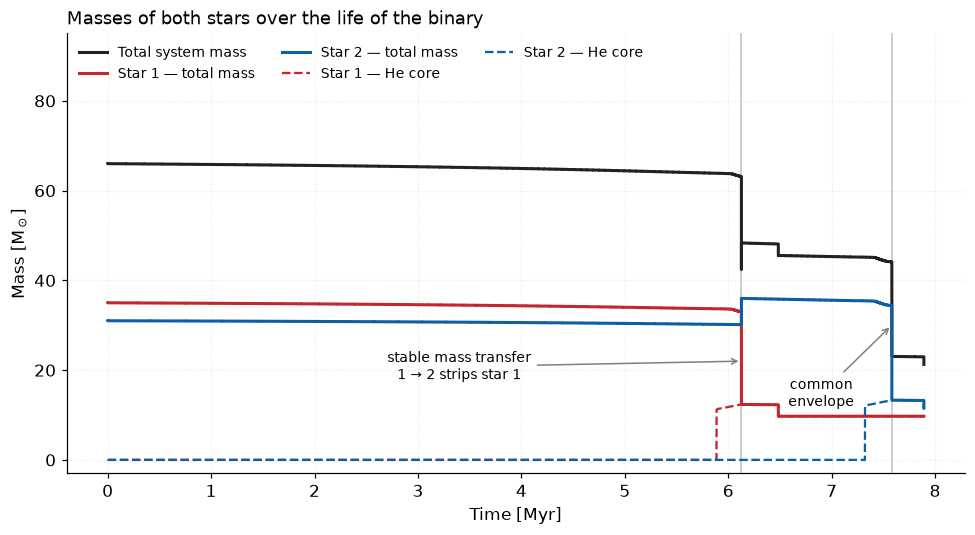

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df.Time, df["Mass(1)"] + df["Mass(2)"], color=CSYS, lw=2, label="Total system mass")
ax.plot(df.Time, df["Mass(1)"], color=C1, lw=2, label="Star 1 — total mass")
ax.plot(df.Time, df["Mass(2)"], color=C2, lw=2, label="Star 2 — total mass")
ax.plot(df.Time, df["Mass_He_Core(1)"], color=C1, lw=1.5, ls="--", label="Star 1 — He core")
ax.plot(df.Time, df["Mass_He_Core(2)"], color=C2, lw=1.5, ls="--", label="Star 2 — He core")

# annotate the two interaction episodes
for _, ev in events[events.event.str.startswith("***")].iterrows():
    ax.axvline(ev["Time [Myr]"], color="grey", lw=1, ls="-", alpha=0.5, zorder=0)

ax.set_ylim(-3, 95)  # headroom so the legend sits clear above the data
ax.annotate("stable mass transfer\n1 → 2 strips star 1",
            xy=(6.13, 22), xytext=(3.4, 18), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1))
ax.annotate("common\nenvelope", xy=(7.58, 30), xytext=(6.9, 12), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1))

ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"Mass [M$_\odot$]")
ax.set_title("Masses of both stars over the life of the binary", loc="left", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

**What to notice** (compare with the GWLandscape interactive panel in §2.2 — it should match!):

- For the first ~6 Myr the lines are nearly flat and gently *declining*: that is **stellar winds**,
  slowly carrying mass away. At Z = 0.001 they are weak, which is exactly why the stars stay heavy.
- At **6.13 Myr** star 1 (red) falls off a cliff while star 2 (blue) jumps up. **Mass is moving
  from one star to the other.** The black total-mass line drops too — mass transfer is not fully
  conservative; some material leaves the system entirely.
- The **dashed He core lines appear** once each star's core is exposed. Notice star 1's red solid
  line converges onto its dashed core line — that *is* what "stripped of its envelope" means: the
  star has become its own core.
- The final vertical drops are the **supernovae/collapses** — mass disappears into the black holes
  and is carried away by neutrinos and ejecta.

## 3.6 Plot 2 — Radii and Roche lobes: *why* mass transfer happens

This is the diagnostic plot of binary evolution. Plot each star's **radius** together with its
**Roche lobe radius**. The rule from §0.5:

> When a star's radius (solid) reaches its Roche lobe (dashed), **mass transfer starts.**

We use a **logarithmic y-axis** because the radii span from ~1 to ~1000 $R_\odot$— three orders
of magnitude. A linear axis would squash all the interesting early detail into a flat line.

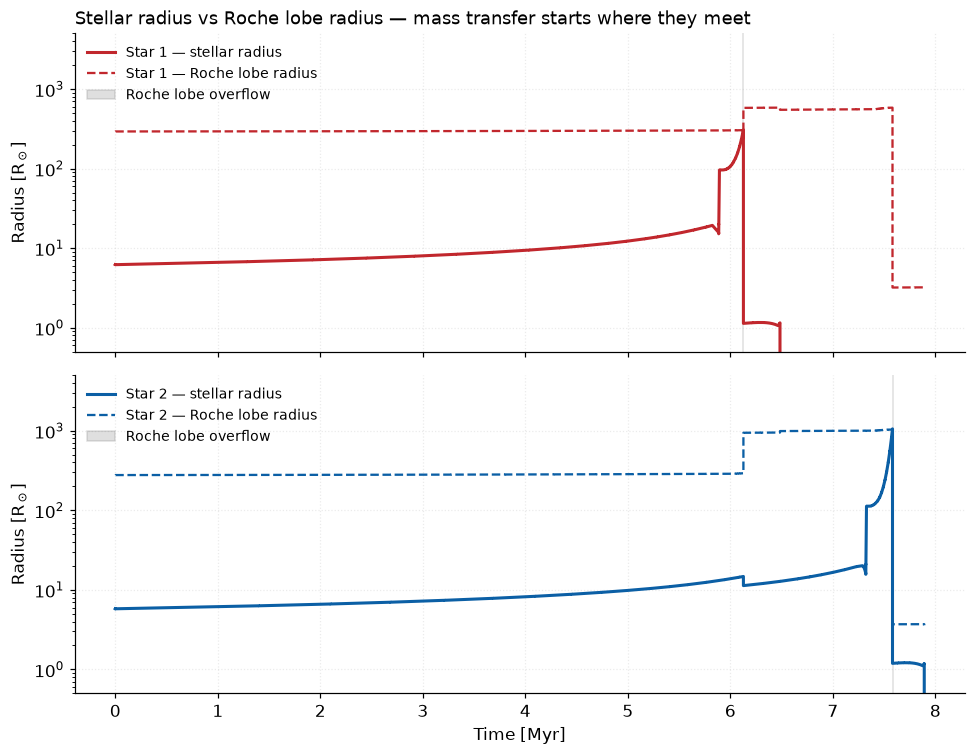

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

for ax, star, colour in [(axes[0], 1, C1), (axes[1], 2, C2)]:
    ax.plot(df.Time, df[f"Radius({star})"], color=colour, lw=2,
            label=f"Star {star} — stellar radius")
    ax.plot(df.Time, df[f"RocheLobe({star})"], color=colour, lw=1.5, ls="--",
            label=f"Star {star} — Roche lobe radius")

    # shade the intervals where this star overflows its Roche lobe
    overflowing = df[f"Radius({star})"] >= df[f"RocheLobe({star})"]
    ax.fill_between(df.Time, 1e-2, 1e4, where=overflowing, color="grey", alpha=0.25,
                    label="Roche lobe overflow", zorder=0)

    ax.set_yscale("log")
    ax.set_ylim(0.5, 5e3)
    ax.set_ylabel(r"Radius [R$_\odot$]")
    ax.legend(loc="upper left", fontsize=9)

axes[0].set_title("Stellar radius vs Roche lobe radius — mass transfer starts where they meet",
                  loc="left", fontsize=12)
axes[1].set_xlabel("Time [Myr]")
plt.tight_layout()
plt.show()

**What to notice:**

- **Top panel (star 1):** the red solid line climbs steeply from ~6  $R_\odot$ to ~300  $R_\odot$ as
  the star leaves the main sequence and becomes a giant. It slams into the dashed Roche lobe line
  at **6.13 Myr** — and mass transfer begins (shaded band). Immediately after, the radius
  **collapses to ~1  $R_\odot$**: the bloated envelope is gone, and what is left is the small, dense,
  hot helium core.
- **Bottom panel (star 2):** star 2 does the same thing later, at ~7.58 Myr, reaching over
  1000  $R_\odot$. But by then its companion is a **black hole**, and this episode is unstable — it
  becomes the **common envelope**.
- **The Roche lobe radii (dashed) are not constant** — they move! The Roche lobe depends on both
  the separation and the mass ratio, so every time mass moves or the orbit changes, the Roche
  lobes resize. Binary evolution is a feedback loop: radius → mass transfer → orbit → Roche lobe →
  radius.
- **A note on the clipped axis:** we cut the y-axis off at 0.5  $R_\odot$. Once a star collapses,
  COMPAS reports the *compact object's* radius — about 4 × 10⁻⁵  $R_\odot$, a few kilometres — so
  those lines plunge off the bottom of the plot. That is not a bug: a black hole really is that
  small. Leaving the axis unclipped would squash everything else into the top sliver of the
  figure. **Choosing sensible axis limits is part of making an honest plot** — just say what you
  clipped, as we do here.

## 3.7 Plot 3 — The orbit: separation and eccentricity

Now the orbit itself. This plot contains the single most dramatic number in the dataset.

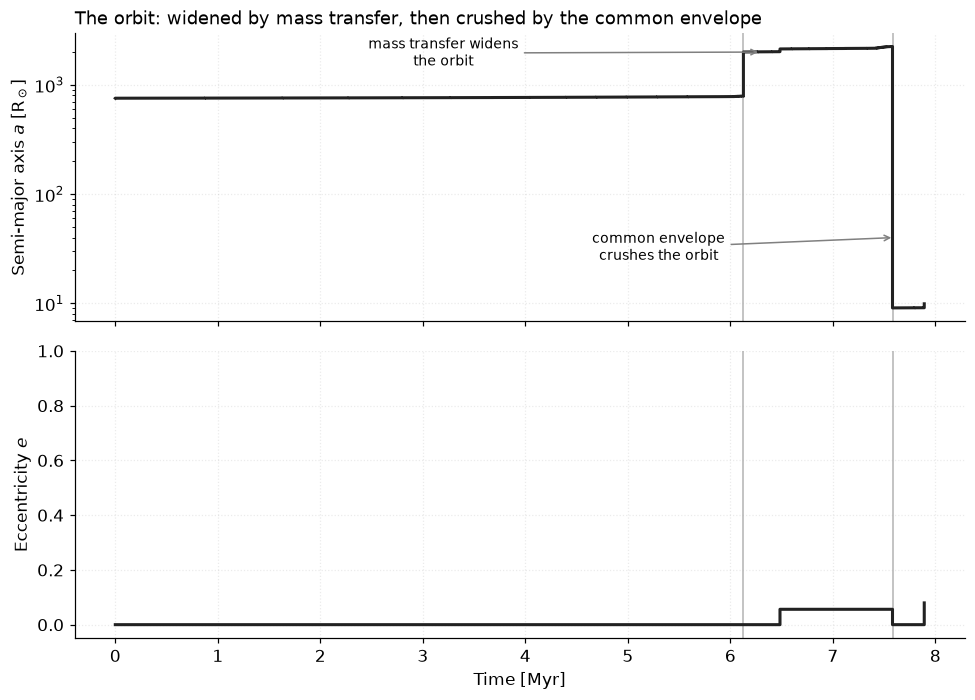

Separation just before the common envelope :  2109.80 Rsun
Separation just after  the common envelope :     9.09 Rsun
  --> the CE shrank the orbit by a factor of 232.1
Final separation of the binary black hole   :     9.91 Rsun


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)

axes[0].plot(df.Time, df["SemiMajorAxis"], color=CSYS, lw=2)
axes[0].set_yscale("log")
axes[0].set_ylabel(r"Semi-major axis $a$ [R$_\odot$]")
axes[0].set_title("The orbit: widened by mass transfer, then crushed by the common envelope",
                  loc="left", fontsize=12)

axes[1].plot(df.Time, df["Eccentricity"], color=CSYS, lw=2)
axes[1].set_ylabel("Eccentricity $e$")
axes[1].set_xlabel("Time [Myr]")
axes[1].set_ylim(-0.05, 1.0)

for ax in axes:
    for _, ev in events[events.event.str.startswith("***")].iterrows():
        ax.axvline(ev["Time [Myr]"], color="grey", lw=1, alpha=0.6, zorder=0)

axes[0].annotate("mass transfer widens\nthe orbit", xy=(6.3, 1990), xytext=(3.2, 1500),
                 fontsize=9, ha="center",
                 arrowprops=dict(arrowstyle="->", color="grey", lw=1))
axes[0].annotate("common envelope\ncrushes the orbit", xy=(7.6, 40), xytext=(5.3, 25),
                 fontsize=9, ha="center",
                 arrowprops=dict(arrowstyle="->", color="grey", lw=1))

plt.tight_layout()
plt.show()

# Find the common envelope from the data itself (MT_History == 4), rather than
# hard-coding a time: the row before it starts is the orbit "just before" the CE.
ce_start = np.where(df["MT_History"].values == 4)[0][0]
a_before = df["SemiMajorAxis"].iloc[ce_start - 1]
a_at_ce = df["SemiMajorAxis"].iloc[ce_start]
a_final = df["SemiMajorAxis"].iloc[-1]

# 8.2f means 8 characters wide, 2 decimal places, right-aligned. The colon separates the width from the format specifier.
print(f"Separation just before the common envelope : {a_before:8.2f} Rsun")
print(f"Separation just after  the common envelope : {a_at_ce:8.2f} Rsun")
print(f"  --> the CE shrank the orbit by a factor of {a_before / a_at_ce:.1f}")
print(f"Final separation of the binary black hole   : {a_final:8.2f} Rsun")

**What to notice:**

- The **common envelope is violent**: it shrinks the orbit by a factor of over 200 in a fraction
  of a Myr. This is *the* reason common envelope matters so much. Two black holes 2150 $R_\odot$
  apart would take vastly longer than the age of the Universe to merge via gravitational waves.
  At ~10 $R_\odot$, they will merge in a time we can actually observe. **The common envelope is
  what makes this system a LIGO source.**
- The **eccentricity** stays ~0 for most of the evolution (the orbit was born circular) and then
  jumps at each supernova — the sudden mass loss and natal kick knock the orbit out of round.

> ⚠️ **A caveat you should carry with you.** The common envelope efficiency parameters ($\alpha$,
> $\lambda$) are *deeply uncertain*. Change them, and that factor-of-230 becomes a different
> number — or the stars merge instead of surviving. **This single uncertain step swings predicted
> merger rates by orders of magnitude.** Mapping that uncertainty is a large part of why GROWL
> exists.

## 3.8 Plot 4 — The Hertzsprung–Russell (HR) diagram

The **HR diagram** is the most important plot in all of stellar astrophysics. It plots a star's
**luminosity** (total energy radiated per second, in units of the Sun's, $L_\odot$) against its
**effective temperature** (the temperature of its visible surface, in Kelvin).

Two conventions that trip everyone up the first time:

1. **The temperature axis is reversed** — hot on the *left*, cool on the *right*. This is a
   historical accident from when stars were sorted by spectral type, and we are stuck with it.
2. **Both axes are logarithmic**, because stars span an enormous range in both quantities.

A star does not sit still on this diagram: as it evolves it traces out a **track**. Cool and
luminous (top right) = big and puffy (a red giant). Hot and faint (bottom left) = small and dense.

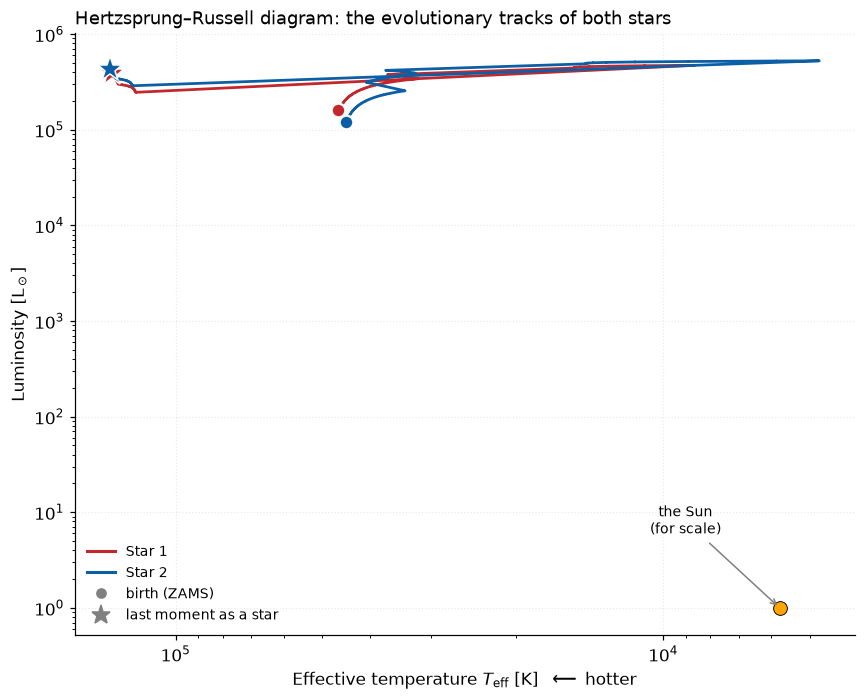

In [10]:
fig, ax = plt.subplots(figsize=(8, 6.5))

# only plot while each object is still a star -- black holes have no meaningful Teff/L
for star, colour, name in [(1, C1, "Star 1"), (2, C2, "Star 2")]:
    is_star = df[f"Stellar_Type({star})"] <= 9
    d = df[is_star]
    ax.plot(d[f"Teff({star})"], d[f"Luminosity({star})"], color=colour, lw=1.8, label=name)
    ax.plot(d[f"Teff({star})"].iloc[0], d[f"Luminosity({star})"].iloc[0],
            "o", color=colour, ms=9, mec="white", mew=1.5) # mec is marker edge color, mew is marker edge width
    ax.plot(d[f"Teff({star})"].iloc[-1], d[f"Luminosity({star})"].iloc[-1],
            "*", color=colour, ms=17, mec="white", mew=1)

# the Sun, for scale -- note how far below these massive stars it sits
ax.plot(5772, 1.0, "o", color="orange", ms=9, mec="black", mew=0.6)
ax.annotate("the Sun\n(for scale)", xy=(5772, 1.0), xytext=(9000, 6), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1)) # xy is the point being annotated, xytext is where the text is placed, ha is horizontal alignment of the text

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()  # HR convention: hot on the LEFT
ax.set_xlabel(r"Effective temperature $T_{\rm eff}$ [K]  $\longleftarrow$ hotter")
ax.set_ylabel(r"Luminosity [L$_\odot$]")
ax.set_title("Hertzsprung–Russell diagram: the evolutionary tracks of both stars",
             loc="left", fontsize=12)

handles = [Line2D([], [], color=C1, lw=2, label="Star 1"),
           Line2D([], [], color=C2, lw=2, label="Star 2"),
           Line2D([], [], color="grey", marker="o", ls="none", label="birth (ZAMS)"),
           Line2D([], [], color="grey", marker="*", ls="none", ms=13, label="last moment as a star")]
ax.legend(handles=handles, loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

**How to read this track:**

- Both stars **start** (circles) in the upper-left region: hot (~45,000 K — about eight times the
  Sun's surface temperature) and blazingly luminous (~1.5 × 10⁵ $L_\odot$). That is what a
  30+ $M_\odot$ main-sequence star is — over a hundred thousand Suns. For scale, the actual Sun is
  the small orange dot in the lower right. Almost the entire lower half of this diagram, where
  most stars in the Universe live, is empty here: our two stars are extreme objects.
- They then move **right** — getting cooler (down to ~5,000–9,000 K) while staying luminous. That
  is the star **expanding** into a giant: the same energy output spread over a far larger surface
  means a cooler surface. This rightward march is what drives the star into its Roche lobe.
- Then each track shoots **hard to the left**, to extreme temperatures (~135,000 K). That is the
  moment the envelope is stripped away and we are suddenly looking straight at the **naked helium
  core** — a small, ferociously hot object.
- The **star** markers are the last moment each object exists as a star. Immediately after, it
  collapses into a black hole and leaves the diagram entirely — a black hole has no surface and no
  luminosity, so it simply cannot be plotted here.

## 3.9 Putting it all together

Finally, the summary figure: everything on a shared time axis, so you can see how the pieces
interlock. **This is the plot to look at when you want to understand a system.**

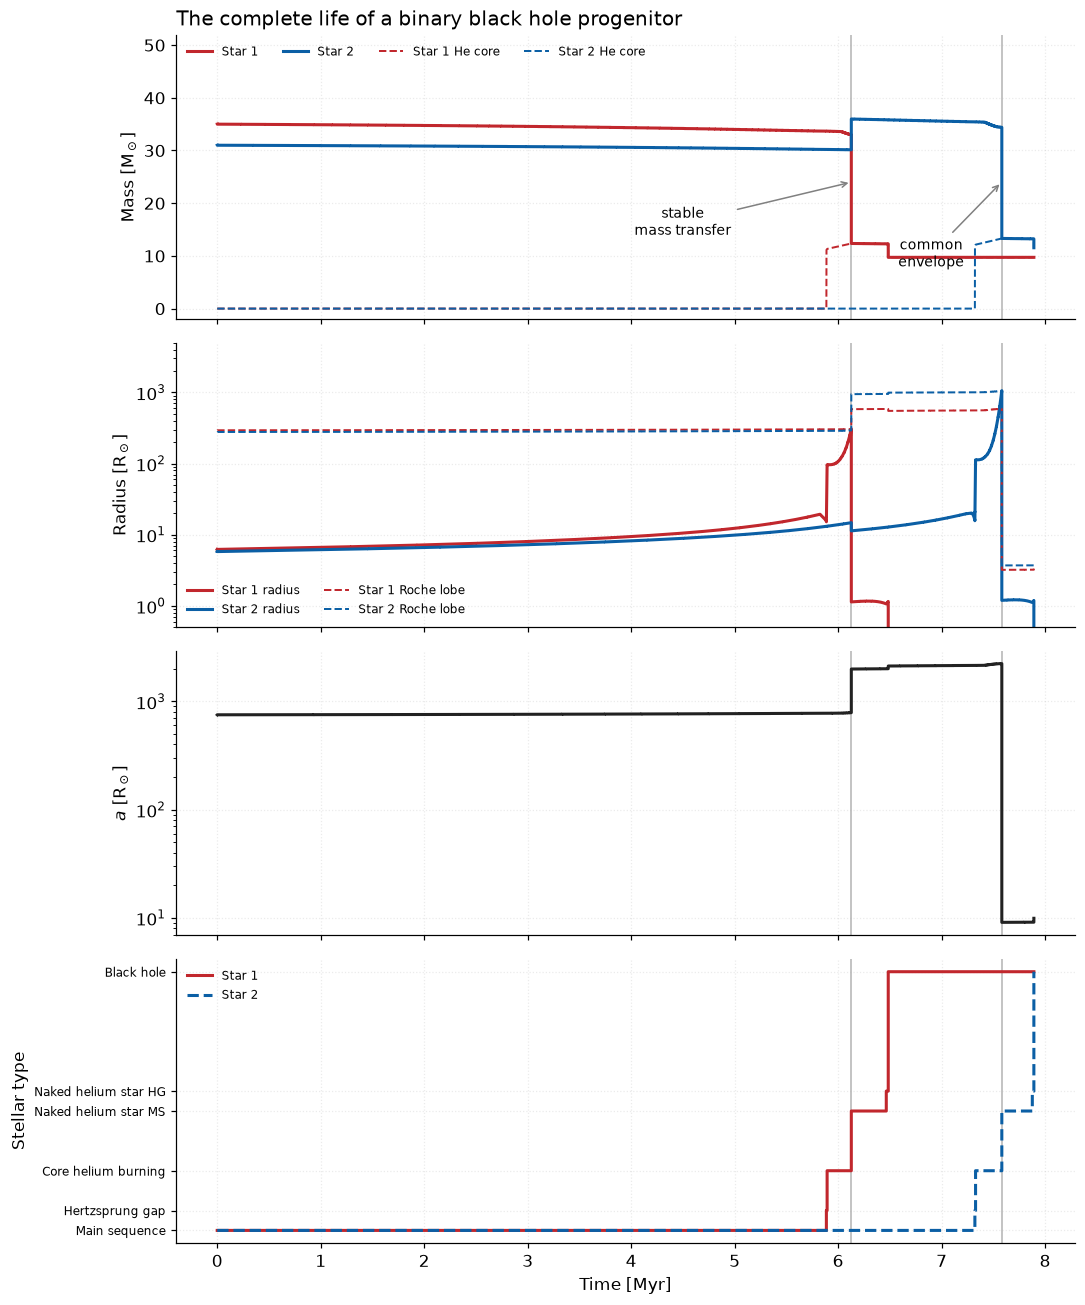

FINAL STATE at t = 7.89 Myr
  Star 1: Black hole, 9.73 Msun
  Star 2: Black hole, 11.54 Msun
  Separation: 9.91 Rsun, eccentricity 0.079
  Bound? YES - still a binary


In [11]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# --- panel 1: masses -----------------------------------------------------------
ax = axes[0]
ax.plot(df.Time, df["Mass(1)"], color=C1, lw=2, label="Star 1")
ax.plot(df.Time, df["Mass(2)"], color=C2, lw=2, label="Star 2")
ax.plot(df.Time, df["Mass_He_Core(1)"], color=C1, lw=1.3, ls="--", label="Star 1 He core")
ax.plot(df.Time, df["Mass_He_Core(2)"], color=C2, lw=1.3, ls="--", label="Star 2 He core")
ax.set_ylabel(r"Mass [M$_\odot$]")
ax.set_ylim(-2, 52)  # headroom for the legend and annotations
ax.legend(fontsize=8, ncol=4, loc="upper left")
ax.set_title("The complete life of a binary black hole progenitor", loc="left", fontsize=13)

# --- panel 2: radii and Roche lobes --------------------------------------------
ax = axes[1]
ax.plot(df.Time, df["Radius(1)"], color=C1, lw=2, label="Star 1 radius")
ax.plot(df.Time, df["Radius(2)"], color=C2, lw=2, label="Star 2 radius")
ax.plot(df.Time, df["RocheLobe(1)"], color=C1, lw=1.3, ls="--", label="Star 1 Roche lobe")
ax.plot(df.Time, df["RocheLobe(2)"], color=C2, lw=1.3, ls="--", label="Star 2 Roche lobe")
ax.set_yscale("log")
# Clip the y-axis to stellar radii: after collapse the "radius" is the compact
# object's (~1e-4 Rsun, a few km), which would otherwise squash the whole panel.
ax.set_ylim(0.5, 5e3)
ax.set_ylabel(r"Radius [R$_\odot$]")
ax.legend(fontsize=8, ncol=2, loc="lower left")

# --- panel 3: separation -------------------------------------------------------
ax = axes[2]
ax.plot(df.Time, df["SemiMajorAxis"], color=CSYS, lw=2)
ax.set_yscale("log")
ax.set_ylabel(r"$a$ [R$_\odot$]")

# --- panel 4: stellar type -----------------------------------------------------
ax = axes[3]
ax.step(df.Time, df["Stellar_Type(1)"], color=C1, lw=2, where="post", label="Star 1")
ax.step(df.Time, df["Stellar_Type(2)"], color=C2, lw=2, where="post", ls="--", label="Star 2")
visited = sorted(set(df["Stellar_Type(1)"]) | set(df["Stellar_Type(2)"]))
ax.set_yticks(visited)
ax.set_yticklabels([STELLAR_TYPES[t] for t in visited], fontsize=8)
ax.set_ylabel("Stellar type")
ax.set_xlabel("Time [Myr]")
ax.legend(fontsize=8, loc="upper left")

# mark the interaction events across every panel
for ax in axes:
    for _, ev in events[events.event.str.startswith("***")].iterrows():
        ax.axvline(ev["Time [Myr]"], color="grey", lw=1, alpha=0.6, zorder=0)

axes[0].annotate("stable\nmass transfer", xy=(6.13, 24), xytext=(4.5, 14), fontsize=9,
                 ha="center", arrowprops=dict(arrowstyle="->", color="grey", lw=1))
axes[0].annotate("common\nenvelope", xy=(7.58, 24), xytext=(6.9, 8), fontsize=9,
                 ha="center", arrowprops=dict(arrowstyle="->", color="grey", lw=1))

plt.tight_layout()
plt.show()

print(f"FINAL STATE at t = {df.Time.iloc[-1]:.2f} Myr")
print(f"  Star 1: {STELLAR_TYPES[df['Stellar_Type(1)'].iloc[-1]]}, {df['Mass(1)'].iloc[-1]:.2f} Msun")
print(f"  Star 2: {STELLAR_TYPES[df['Stellar_Type(2)'].iloc[-1]]}, {df['Mass(2)'].iloc[-1]:.2f} Msun")
print(f"  Separation: {df['SemiMajorAxis'].iloc[-1]:.2f} Rsun, eccentricity {df['Eccentricity'].iloc[-1]:.3f}")
print(f"  Bound? {'NO - disrupted' if df['Unbound'].iloc[-1] else 'YES - still a binary'}")

<a id="exercises"></a>
# Part 4 — Your turn 🎓

These exercises are the actual point of the notebook. Work through them; bring your plots and
questions to the next onboarding session.

### Exercise 1 — Make a plot of your own (required)

Pick a quantity from §3.2 that we did **not** plot and make a figure of it against time, with a
sentence or two explaining what it shows. Good candidates:

- `Luminosity(1)` and `Luminosity(2)` vs time (use a log y-axis).
- `Teff(1)` and `Teff(2)` vs time — when is each star hottest, and why?
- `Mass_CO_Core` vs `Mass_He_Core` — how does the onion-layer structure build up?
- `Mass_Env(1)` (the envelope mass) — watch it get stripped to zero.
- The **mass ratio** $q = M_2/M_1$ vs time. Mark the moment it crosses 1.

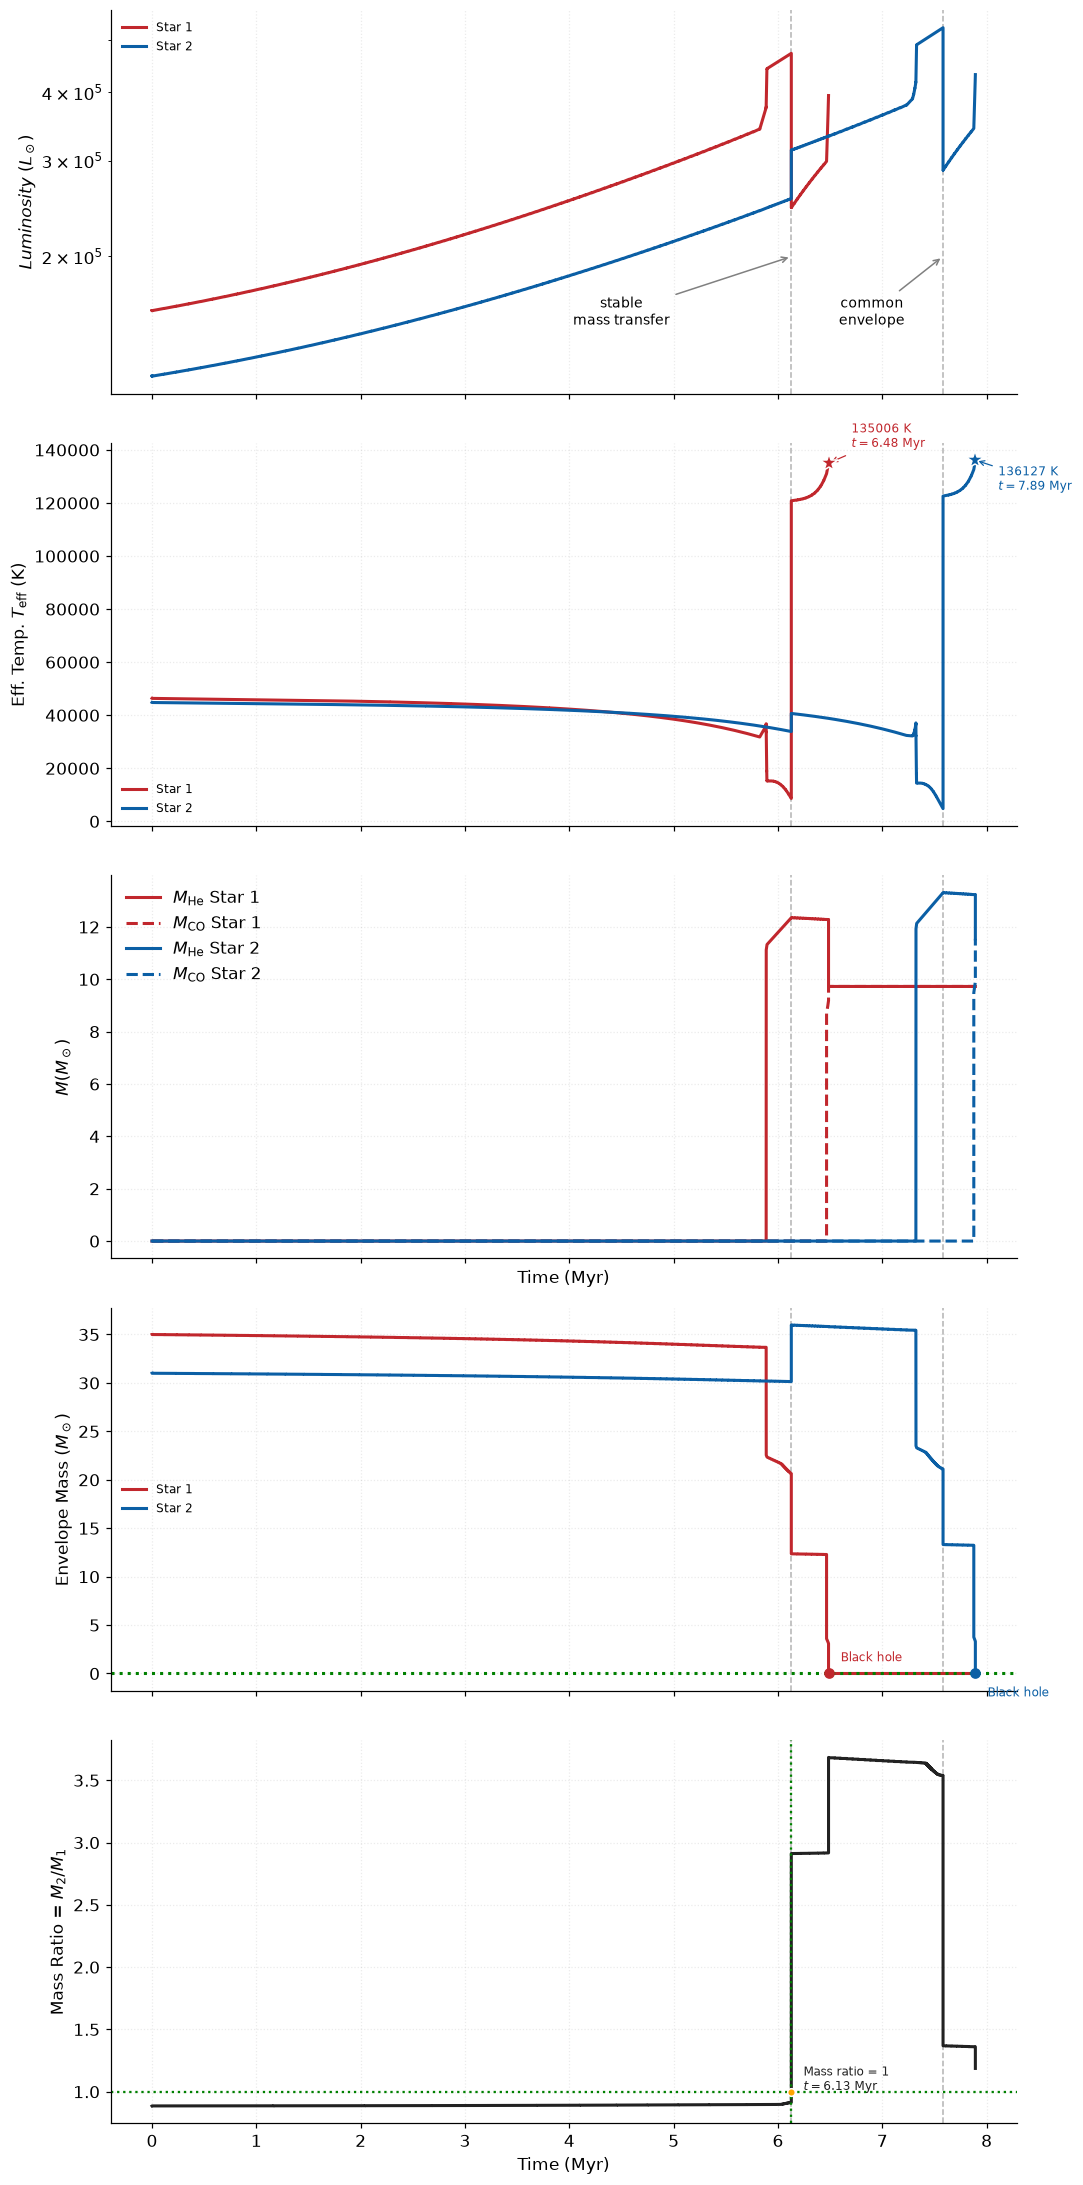

In [53]:
with h5py.File(DATA_PATH, "r") as f:
    mass_env_1 = f["Mass_Env(1)"][()]
    mass_env_2 = f["Mass_Env(2)"][()]
    ang_1 = f["Ang_Momentum(1)"][()]
    ang_2 = f["Ang_Momentum(2)"][()]
    ang_sys = f["Ang_Momentum_Total"][()]

mass_ratio = df["Mass(2)"] / df["Mass(1)"]

# introducing a mask to filter out the black holes and neutron stars
# which have no meaningful luminosity or temperature
mask1 = df["Stellar_Type(1)"] <= 9
mask2 = df["Stellar_Type(2)"] <= 9

fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)

# --- panel 1: luminosity vs time -----------------------------------------------------
ax = axes[0]
ax.plot(df.Time[mask1], df["Luminosity(1)"][mask1], color=C1, lw=2, label="Star 1")
ax.plot(df.Time[mask2], df["Luminosity(2)"][mask2], color=C2, lw=2, label="Star 2")
ax.set_yscale("log")
ax.set_ylabel(r"$Luminosity \ (L_\odot)$")
ax.legend(fontsize=8, loc="upper left")

# --- panel 2: effective temperature vs time -----------------------------------------------------
ax = axes[1]
ax.plot(df.Time[mask1], df["Teff(1)"][mask1], color=C1, lw=2, label="Star 1")
ax.plot(df.Time[mask2], df["Teff(2)"][mask2], color=C2, lw=2, label="Star 2")
# ax.set_yscale("log")
ax.set_ylabel(r"Eff. Temp. $T_{\rm eff}$ (K)")
ax.legend(fontsize=8, loc="lower left")

# annotating the maximum effective temperature for each star, which is often of interest in stellar evolution studies
# giving different offsets for the annotations so they don't ever overlap
stars = [("Teff(1)", mask1, C1, (15, 10)),
         ("Teff(2)", mask2, C2, (15, -20))]

for teff_col, mask, color, offset in stars:

    idx = df.loc[mask, teff_col].idxmax()

    t = df.loc[idx, "Time"]
    Teff = df.loc[idx, teff_col]

    ax.plot(t, Teff,
        marker="*",
        color=color,
        markersize=12,
        markeredgecolor="white",
        zorder=5,)

    ax.annotate( f"{Teff:.0f} K\n$t={t:.2f}$ Myr",
        xy=(t, Teff),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
        color=color,
        arrowprops=dict(arrowstyle="->", lw=0.8, color=color),
    )

# --- panel 3: core masses vs time -----------------------------------------------------
ax = axes[2]
for star, color in [(1, C1), (2, C2)]:
    ax.plot(df.Time, df[f"Mass_He_Core({star})"], color=color, ls="-", lw=2, label=fr"$M_{{\rm He}}$ Star {star}")
    ax.plot(df.Time, df[f"Mass_CO_Core({star})"], color=color, ls="--", lw=2, label=fr"$M_{{\rm CO}}$ Star {star}")

ax.set_xlabel(r"Time (Myr)")
ax.set_ylabel(r"$M(M_\odot)$")
ax.legend()

# --- panel 4: envelope mass vs time -----------------------------------------------------
ax = axes[3]
ax.plot(df.Time, mass_env_1, color=C1, lw=2, label="Star 1")
ax.plot(df.Time, mass_env_2, color=C2, lw=2, label="Star 2")
ax.axhline(y=0, color="green", ls=":", lw=2)
ax.set_ylabel(r"Envelope Mass ($M_\odot$)")
ax.legend(fontsize=8, loc="center left")

# option for ls are 

# annotating the stellar type at the moment when the envelope mass reaches zero for each star
stars = [
    (mass_env_1, "Stellar_Type(1)", C1, (8, 8)),
    (mass_env_2, "Stellar_Type(2)", C2, (8, -15)),
]

for env_mass, stype_col, color, offset in stars:

    # finding the first row where envelope mass is zero
    # np.where returns the indices where the condition is True,
    # np.isclose is used to avoid floating point comparison issues
    indices = np.where(np.isclose(env_mass, 0))[0]
    if len(indices):
        idx = indices[0]

    t = df.loc[idx, "Time"]
    stype = STELLAR_TYPES[df.loc[idx, stype_col]]

    ax.plot(t, 0, marker="o", color=color, markersize=6)

    ax.annotate(
        stype,
        xy=(t, 0),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
        color=color,
    )

# --- panel 5: mass ratio vs time -----------------------------------------------------
ax = axes[4]
ax.plot(df.Time, mass_ratio, lw=2, color = CSYS)
ax.axhline(y=1, color="green", ls=":", lw=1.5)
ax.set_ylabel(r"Mass Ratio = $M_2/M_1$")
ax.set_xlabel("Time (Myr)")

# using cross instead of np.where(np.isclose(mass_ratio, 1)) to find where the mass ratio crosses 1,
# because it is not necessary that mass_ratio = 1 instance is exactly in the data or is even present
#  in the tolerance of floating point comparison, so we look for where it crosses 1 by checking the sign change
cross = np.where(np.diff(np.sign(mass_ratio - 1)) != 0)[0]

if len(cross):
    i = cross[0]

    # using linear interpolation to find the exact time when mass ratio = 1
    t1, t2 = df.loc[i, "Time"], df.loc[i+1, "Time"]
    r1, r2 = mass_ratio[i], mass_ratio[i+1]

    t_equal = t1 + (1 - r1) * (t2 - t1) / (r2 - r1)

    ax.axvline(t_equal, color="green", ls=":", lw=1.5)
    ax.plot(t_equal, 1, marker="o", color= "orange", markersize=5, markeredgecolor="white", zorder=5)
    ax.annotate(
        f"Mass ratio = 1\n$t={t_equal:.2f}$ Myr",
        xy=(t_equal, 1),
        xytext=(8, 0.5),
        textcoords="offset points",
        fontsize=8,
        color=CSYS,
        #arrowprops=dict(arrowstyle="->", lw=0.8, color="green"),
    )


# mark the interaction events across every panel
for ax in axes:
    for _, ev in events[events.event.str.startswith("***")].iterrows():
        ax.axvline(ev["Time [Myr]"], color="grey", ls = '--', lw=1, alpha=0.6, zorder=0)

axes[0].annotate("stable\nmass transfer", xy=(6.13, 2*1e5), xytext=(4.5, 1.5*1e5), fontsize=9,
                 ha="center", arrowprops=dict(arrowstyle="->", color="grey", lw=1))
axes[0].annotate("common\nenvelope", xy=(7.58, 2*1e5), xytext=(6.9, 1.5*1e5), fontsize=9,
                 ha="center", arrowprops=dict(arrowstyle="->", color="grey", lw=1))

plt.tight_layout()
plt.show()

## Discussion of Binary Evolution Plots

### **Panel 1: Luminosity ($L/L_\odot$) vs. Time (Myr)**

The luminosities of both stars increase gradually during their main-sequence evolution as the core contracts and the mean molecular weight increases, requiring a higher energy generation rate to maintain hydrostatic equilibrium. Each star subsequently undergoes a sharp increase in luminosity as it enters the helium-burning (red giant) phase, driven by shell hydrogen burning and core contraction. The onset of **stable mass transfer** (Star 1) and the **common-envelope** phase (Star 2) produces abrupt decreases in luminosity as their hydrogen-rich envelopes are stripped, while the accreting companion temporarily brightens due to the addition of fresh mass. Following envelope removal, the stars briefly evolve as hot helium stars before collapsing into black holes, terminating their stellar evolution.

### **Panel 2: Effective Temperature ($T_{\rm eff}$) vs. Time (Myr)**

The effective temperatures remain nearly constant throughout the main-sequence phase before decreasing as the stars expand into red giants. Although the luminosity increases, the stellar radius increases by an even larger factor; consequently, the effective temperature decreases according to the Stefan-Boltzmann law,

$$
L = 4\pi R^2 \sigma T_{\rm eff}^4.
$$

Stable mass transfer and the common-envelope phase subsequently remove the cool outer envelopes, exposing the much hotter helium cores and producing a sharp increase in effective temperature. Both stars attain their maximum temperatures immediately before core collapse and black hole formation.

### **Panel 3: Helium Core and Carbon–Oxygen Core Masses vs. Time (Myr)**

The helium and carbon-oxygen core masses remain negligible throughout the main-sequence phase because hydrogen fusion occurs within the stellar core without yet producing extended helium or carbon-oxygen cores. As each star evolves, it develops an **onion-like internal structure**, in which progressively heavier elements are synthesized in nested layers. A helium core forms first after core hydrogen exhaustion, followed by the growth of a carbon-oxygen core within it as helium fusion proceeds through the triple-$\alpha$ process. Star 1 develops these cores earlier because its higher initial mass results in faster nuclear evolution. The final carbon-oxygen core masses largely determine the masses of the black holes formed after core collapse.

### **Panel 4: Envelope Mass ($M_{\rm env}$) vs. Time (Myr)**

The envelope masses remain nearly constant throughout the main-sequence phase, with only a gradual decline due to stellar wind mass loss. As the stars evolve, the envelopes become progressively less massive because nuclear burning converts hydrogen into heavier elements while stellar winds continue to remove material. During stable mass transfer, Star 1 loses a substantial fraction of its hydrogen envelope through Roche-lobe overflow, while Star 2 accretes part of this transferred material. The subsequent common-envelope phase efficiently ejects the remaining envelopes, exposing the stellar cores and reducing the envelope masses to zero prior to black hole formation.

### **Panel 5: Mass Ratio ($M_2/M_1$) vs. Time (Myr)**

The mass ratio remains nearly constant during the primary star's main-sequence evolution, indicating that both stars lose relatively little mass compared to their total masses. It increases rapidly during stable mass transfer as the initially more massive primary transfers mass to the secondary, eventually reversing the mass hierarchy so that the secondary becomes the more massive component. Following the formation of the primary black hole, the mass ratio evolves only gradually due to continued stellar winds and the secondary's evolution before decreasing during the common-envelope phase. The final mass ratio remains greater than unity, indicating that the black hole formed from the initially less massive secondary is ultimately more massive than that formed from the primary—a characteristic outcome of efficient binary mass transfer.



### Exercise 2 — Predict, then check

**Before running anything**, write down your prediction for each, then go back to GWLandscape
(§1.2 "Also try") and test it:

1. If you increase the metallicity to Z = 0.02 (above solar), will the final black holes be
   **more** or **less** massive? Why?  
   **Ans.** Less massive, because higher metallicity will strengthen the stellar winds; making more mass being blown away. 
2. If you start the binary at 35 AU instead of 3.5 AU, will there be a common envelope?
   What will the final separation be? Will these black holes ever merge?  
   **Ans.** Nopes, too far away to interact. Quite large separation post the supernovae. Merger will take a lot of time.
3. If you make the two stars equal mass (33 and 33 $M_\odot$), does star 1 still get stripped first?  
   **Ans.** Surprisingly  they merge.

Download the output of one of these runs and re-run the analysis cells above on it — just change
`DATA_PATH`. Everything else should work unchanged.

### Exercise 3 — Will they merge? (stretch)

Our binary ends as two black holes ($m_1 \approx 9.7$, $m_2 \approx 11.5$ $M_\odot$) with
$a \approx 9.9$ $R_\odot$ and $e \approx 0$. Two black holes in orbit emit **gravitational waves**,
which carry away energy, so the orbit shrinks until they merge. For a circular orbit, Peters
(1964) gives the time to merge as:

$$ t_{\rm merge} = \frac{5}{256} \, \frac{c^5 \, a^4}{G^3 \, m_1 \, m_2 \, (m_1 + m_2)} $$

Compute $t_{\rm merge}$ for our system. **Is it less than the age of the Universe (13.8 Gyr)?**
If so, congratulations — you have just built a LIGO source from scratch. Then try it with the
pre-common-envelope separation of ~2110 $R_\odot$ and see just how much that one event mattered.

*(Watch your units — the formula needs SI. Note $t \propto a^4$: this is why the factor-230
shrink in $a$ matters so enormously. If you have a working `astropy` install, `astropy.units`
and `astropy.constants` will keep your units honest for you; the stub below uses plain SI
constants so that it runs anywhere.)*

In [55]:
# --- Exercise 3: merger time ----------------------------------------------------
# SI constants, so this cell has no extra dependencies.
G_SI = 6.67430e-11      # m^3 kg^-1 s^-2
C_SI = 2.99792458e8     # m s^-1
MSUN = 1.98892e30       # kg
RSUN = 6.957e8          # m
GYR = 3.15576e16        # s
AGE_UNI = 13.8          # Gyr

def merger_time(m1_msun, m2_msun, a_rsun):
    '''Peters (1964) gravitational-wave merger timescale for a circular orbit.

    Formula gives the time in seconds, so we convert to Gyr at the end.
    '''
    m1, m2, a = m1_msun * MSUN, m2_msun * MSUN, a_rsun * RSUN
    t = (5 / 256) * ((a**4  * C_SI**5)/ (G_SI**3 * m1 * m2 * (m1 + m2)))
    return t / GYR


def print_merger_status(label, t_merge):
    print(f"{label} = {t_merge:.3f} Gyr")
    if t_merge < AGE_UNI:
        print("✓ Merges within the age of the Universe.\n")
    else:
        print("✗ Does not merge within the age of the Universe.\n")


t_fin = merger_time(df["Mass(1)"].iloc[-1], df["Mass(2)"].iloc[-1], df["SemiMajorAxis"].iloc[-1])
t_pre = merger_time(df["Mass(1)"].iloc[-1], df["Mass(2)"].iloc[-1], df["SemiMajorAxis"].iloc[ce_start - 1])
t_pre_prop = merger_time(df["Mass(1)"].iloc[ce_start - 1], df["Mass(2)"].iloc[ce_start - 1], df["SemiMajorAxis"].iloc[ce_start - 1])


print_merger_status("True merger time", t_fin)
print()
print_merger_status("Pre-CE merger time", t_pre)
print()
print_merger_status("Pre-CE proper merger time", t_pre_prop)

True merger time = 0.606 Gyr
✓ Merges within the age of the Universe.


Pre-CE merger time = 1245269377.090 Gyr
✗ Does not merge within the age of the Universe.


Pre-CE proper merger time = 201415832.230 Gyr
✗ Does not merge within the age of the Universe.



In [56]:
from astropy.constants import G, c, M_sun, R_sun
import astropy.units as u

def merger_time_ast(m1, m2, a):
    m1, m2, a = m1 * M_sun, m2 * M_sun, a * R_sun

    t = (5/256) * c**5 * a**4 / (G**3 * m1 * m2 * (m1 + m2))

    return t.to(u.Gyr).value

t_fin = merger_time_ast(df["Mass(1)"].iloc[-1], df["Mass(2)"].iloc[-1], df["SemiMajorAxis"].iloc[-1])
t_pre = merger_time_ast(df["Mass(1)"].iloc[-1], df["Mass(2)"].iloc[-1], df["SemiMajorAxis"].iloc[ce_start - 1])
t_pre_prop = merger_time_ast(df["Mass(1)"].iloc[ce_start - 1], df["Mass(2)"].iloc[ce_start - 1], df["SemiMajorAxis"].iloc[ce_start - 1])

print_merger_status("True merger time", t_fin)
print()
print_merger_status("Pre-CE merger time", t_pre)
print()
print_merger_status("Pre-CE proper merger time", t_pre_prop)

True merger time = 0.606 Gyr
✓ Merges within the age of the Universe.


Pre-CE merger time = 1246228049.739 Gyr
✗ Does not merge within the age of the Universe.


Pre-CE proper merger time = 201570892.535 Gyr
✗ Does not merge within the age of the Universe.



<a id="glossary"></a>
# Glossary

| Term | Meaning |
|---|---|
| **AU** | Astronomical unit; the Earth–Sun distance ≈ 215 R$_\odot$. |
| **Binary black hole (BBH)** | Two black holes in orbit. The most common LIGO/Virgo detection. |
| **Common envelope (CE)** | Both stellar cores orbiting inside one shared gas envelope; drag shrinks the orbit dramatically. Highly uncertain. |
| **Compact object** | A white dwarf, neutron star, or black hole. |
| **COMPAS** | *Compact Object Mergers: Population Astrophysics and Statistics* — the rapid population synthesis code used here. |
| **Cosmic integration** | Folding population synthesis results together with the star formation history of the Universe to predict observable rates. |
| **Detailed output** | A COMPAS file recording every quantity at every timestep, for one binary. What we analysed. |
| **HDF5** | A binary file format for large scientific arrays; read with `h5py`. |
| **HR diagram** | Luminosity vs surface temperature; the fundamental diagram of stellar astrophysics. Temperature axis runs backwards. |
| **Mass ratio ($q$)** | $M_2/M_1$. Largely controls mass transfer stability. |
| **Mass transfer** | Gas flowing from one star to its companion, via Roche lobe overflow. |
| **Metallicity ($Z$)** | Mass fraction of elements heavier than helium. Solar ≈ 0.014. Controls winds, radii, and final masses. |
| **Myr / Gyr** | Million / billion years. |
| **Naked helium star** | A star stripped of its hydrogen envelope, exposing the helium core. Fingerprint of binary interaction. |
| **Natal kick** | The velocity a compact object receives from an asymmetric supernova. Can disrupt the binary. |
| **Population synthesis** | Simulating many binaries with approximate ("rapid") prescriptions to predict population-level statistics. |
| **Roche lobe** | The teardrop region within which a star's gravity dominates. Filling it starts mass transfer. |
| **Semi-major axis ($a$)** | The size of the orbit; roughly the average separation. |
| **Stellar type** | Integer code for a star's evolutionary phase (Hurley et al. 2000). 1 = main sequence, 14 = black hole. |
| **VIMES** | *VIsualization of Massive Evolving Stars* — makes animations from COMPAS output. |
| **ZAMS** | Zero-age main sequence: the moment a star starts fusing hydrogen. Our $t = 0$. |

# ✅ Summary — what you did

1. Learned that **population synthesis** trades detailed stellar physics for **speed**, so that
   millions of binaries can be evolved and compared to real populations.
2. Ran the real COMPAS code in your browser via **GWLandscape**, and learned what each initial
   parameter physically means — especially **metallicity**.
3. Read the output three ways: the **event summary**, the **interactive figures**, and a **VIMES
   movie**.
4. Opened the raw **HDF5** file yourself and rebuilt those figures from first principles.
5. Followed one binary from two ordinary massive stars, through **stable mass transfer**, a
   **black hole formation**, a **common envelope**, and a second **black hole formation**, to a
   tight **binary black hole** — the canonical isolated-binary formation channel.

# ➡️ Next steps

- **Notebook 2:** (TBD) `introduction_to_stellar_evolution_simulations.ipynb` — moving from *one* binary
  to *populations* of millions, and reading published COMPAS datasets.

### Questions?

Common envelope evolution is a very challenging concept, so if that part felt confusing, you are in
excellent company. Bring your questions — and your Exercise 1 plot — to the next onboarding
session.

---
*GROWL onboarding notebook 1 · data: `BSE_Detailed_Output_0.h5`, COMPAS via
[GWLandscape](https://gwlandscape.org.au/)*